In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))


In [3]:
# GPU 활성화 끄기
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] ="-1"
# GPU 사용 여부 확인
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')


2.10.0


[]

# 1. 기존의 프로그램 방식 

In [19]:
import numpy as np
import matplotlib.pyplot as plt


In [20]:
# 섭씨온도(input data)를 받아 화씨 온도로 출력
def celsius_to_faherenheit(c):
    return 1.8*c + 32

In [21]:
input_data = int(input('섭씨 온도는? '))
print('화씨 온도는 ', celsius_to_faherenheit(input_data))

섭씨 온도는? 1
화씨 온도는  33.8


# 2.머신러닝 / 딥러닝 프로그램 방식
- 1. 데이터 확보 및 생성
- 2. 데이터 전처리 : scale조정, 라벨링처리, 훈련데이터셋(학습데이터셋), 검증데이터셋, 시럼데이터셋으로 나누기
- 3. 모델구성
- 4. 모델 학습과정 설정
- 5. 모델 학습스키기 (학습데이터셋과 검증데이터셋)
- 6. 모델 평가(시험데이터셋)
- 7. 모델 사용(입력값이 주어지면 예측값을 받기)
## 2.1 노이즈가 없는 데이터로 실습

In [22]:
# 1. 데이터 생성
data_C = np.arange(100)
data_C # 입력변수==독립변수

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [23]:
data_F = celsius_to_faherenheit(data_C)
data_F

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [11]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해, Normallize함(변수들의 편차를 비슷하게)
scaled_data_C = data_C/100.0
scaled_data_F = data_F/100.0
print('독립변수는 ', scaled_data_C)
print('종속변수는 ', scaled_data_F)

독립변수는  [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
종속변수는  [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688 1.706 1.7

In [24]:
# 3. 모델 구성 (tensorflow)
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense, Input # 입력값과 출력값으로 layer층 지정
model =Sequential()
model.add(Dense(1, # 출력(종속, 타겟)변수의 갯수 
                input_shape=(1,)
                ))
print(model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


- 회귀분석 오치함수 :
    MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE단점이 어느정도 해소. 덜 민감), MAE(절대값평균)

In [25]:
# 4. 모델 학습 과정 설정
model.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
              # 손실함수   옵티마이저             평가지표
# loss(오차, 손실함수)는 모델 학습 중 최적화할 대상
# metrics : 평가지표

In [26]:
# 학습 전 예측 
model.predict(np.array([[0],
                       [0.01]]))

1/1 [==============================] - 0s 54ms/step


array([[ 0.        ],
       [-0.01686864]], dtype=float32)

In [27]:
# 학습 전 모델 저장
model.save('model/before_learning.h5') # kermel에 w(기울기), bias에 b이 있음
# from tnesorflow.keras.model import save_model
# save_model(model, 'model/before_learning.h5')

In [28]:
# 모델 학습 시키기 - 1번만 실행
hist = model.fit(scaled_data_C, scaled_data_F, epochs=1000, verbose=2)
                 # 독립변수       타겟변수(종속) 학습횟수    학습시출력여부

Epoch 1/1000
4/4 - 0s - loss: 5.1809 - mae: 2.0416 - 473ms/epoch - 118ms/step
Epoch 2/1000
4/4 - 0s - loss: 5.1338 - mae: 2.0314 - 7ms/epoch - 2ms/step
Epoch 3/1000
4/4 - 0s - loss: 5.0937 - mae: 2.0222 - 9ms/epoch - 2ms/step
Epoch 4/1000
4/4 - 0s - loss: 5.0683 - mae: 2.0165 - 6ms/epoch - 1ms/step
Epoch 5/1000
4/4 - 0s - loss: 5.0418 - mae: 2.0105 - 6ms/epoch - 2ms/step
Epoch 6/1000
4/4 - 0s - loss: 5.0141 - mae: 2.0041 - 7ms/epoch - 2ms/step
Epoch 7/1000
4/4 - 0s - loss: 4.9853 - mae: 1.9976 - 6ms/epoch - 1ms/step
Epoch 8/1000
4/4 - 0s - loss: 4.9614 - mae: 1.9921 - 7ms/epoch - 2ms/step
Epoch 9/1000
4/4 - 0s - loss: 4.9361 - mae: 1.9864 - 5ms/epoch - 1ms/step
Epoch 10/1000
4/4 - 0s - loss: 4.9089 - mae: 1.9801 - 7ms/epoch - 2ms/step
Epoch 11/1000
4/4 - 0s - loss: 4.8818 - mae: 1.9738 - 6ms/epoch - 1ms/step
Epoch 12/1000
4/4 - 0s - loss: 4.8571 - mae: 1.9681 - 5ms/epoch - 1ms/step
Epoch 13/1000
4/4 - 0s - loss: 4.8317 - mae: 1.9622 - 5ms/epoch - 1ms/step
Epoch 14/1000
4/4 - 0s - loss:

Epoch 110/1000
4/4 - 0s - loss: 2.7305 - mae: 1.4025 - 10ms/epoch - 2ms/step
Epoch 111/1000
4/4 - 0s - loss: 2.7134 - mae: 1.3974 - 8ms/epoch - 2ms/step
Epoch 112/1000
4/4 - 0s - loss: 2.6953 - mae: 1.3918 - 5ms/epoch - 1ms/step
Epoch 113/1000
4/4 - 0s - loss: 2.6774 - mae: 1.3866 - 9ms/epoch - 2ms/step
Epoch 114/1000
4/4 - 0s - loss: 2.6594 - mae: 1.3811 - 9ms/epoch - 2ms/step
Epoch 115/1000
4/4 - 0s - loss: 2.6405 - mae: 1.3753 - 8ms/epoch - 2ms/step
Epoch 116/1000
4/4 - 0s - loss: 2.6262 - mae: 1.3710 - 9ms/epoch - 2ms/step
Epoch 117/1000
4/4 - 0s - loss: 2.6078 - mae: 1.3655 - 10ms/epoch - 2ms/step
Epoch 118/1000
4/4 - 0s - loss: 2.5879 - mae: 1.3594 - 5ms/epoch - 1ms/step
Epoch 119/1000
4/4 - 0s - loss: 2.5708 - mae: 1.3541 - 6ms/epoch - 1ms/step
Epoch 120/1000
4/4 - 0s - loss: 2.5550 - mae: 1.3493 - 6ms/epoch - 2ms/step
Epoch 121/1000
4/4 - 0s - loss: 2.5379 - mae: 1.3442 - 9ms/epoch - 2ms/step
Epoch 122/1000
4/4 - 0s - loss: 2.5201 - mae: 1.3386 - 8ms/epoch - 2ms/step
Epoch 123/

Epoch 218/1000
4/4 - 0s - loss: 1.1873 - mae: 0.8896 - 9ms/epoch - 2ms/step
Epoch 219/1000
4/4 - 0s - loss: 1.1758 - mae: 0.8853 - 6ms/epoch - 2ms/step
Epoch 220/1000
4/4 - 0s - loss: 1.1652 - mae: 0.8813 - 7ms/epoch - 2ms/step
Epoch 221/1000
4/4 - 0s - loss: 1.1565 - mae: 0.8782 - 10ms/epoch - 3ms/step
Epoch 222/1000
4/4 - 0s - loss: 1.1465 - mae: 0.8743 - 8ms/epoch - 2ms/step
Epoch 223/1000
4/4 - 0s - loss: 1.1364 - mae: 0.8704 - 9ms/epoch - 2ms/step
Epoch 224/1000
4/4 - 0s - loss: 1.1259 - mae: 0.8662 - 7ms/epoch - 2ms/step
Epoch 225/1000
4/4 - 0s - loss: 1.1146 - mae: 0.8620 - 8ms/epoch - 2ms/step
Epoch 226/1000
4/4 - 0s - loss: 1.1039 - mae: 0.8580 - 11ms/epoch - 3ms/step
Epoch 227/1000
4/4 - 0s - loss: 1.0946 - mae: 0.8545 - 7ms/epoch - 2ms/step
Epoch 228/1000
4/4 - 0s - loss: 1.0850 - mae: 0.8507 - 7ms/epoch - 2ms/step
Epoch 229/1000
4/4 - 0s - loss: 1.0737 - mae: 0.8463 - 9ms/epoch - 2ms/step
Epoch 230/1000
4/4 - 0s - loss: 1.0635 - mae: 0.8424 - 7ms/epoch - 2ms/step
Epoch 231/

Epoch 326/1000
4/4 - 0s - loss: 0.4570 - mae: 0.5776 - 6ms/epoch - 2ms/step
Epoch 327/1000
4/4 - 0s - loss: 0.4540 - mae: 0.5759 - 6ms/epoch - 2ms/step
Epoch 328/1000
4/4 - 0s - loss: 0.4523 - mae: 0.5749 - 9ms/epoch - 2ms/step
Epoch 329/1000
4/4 - 0s - loss: 0.4499 - mae: 0.5738 - 6ms/epoch - 2ms/step
Epoch 330/1000
4/4 - 0s - loss: 0.4475 - mae: 0.5724 - 6ms/epoch - 2ms/step
Epoch 331/1000
4/4 - 0s - loss: 0.4439 - mae: 0.5705 - 9ms/epoch - 2ms/step
Epoch 332/1000
4/4 - 0s - loss: 0.4411 - mae: 0.5689 - 5ms/epoch - 1ms/step
Epoch 333/1000
4/4 - 0s - loss: 0.4383 - mae: 0.5673 - 6ms/epoch - 2ms/step
Epoch 334/1000
4/4 - 0s - loss: 0.4353 - mae: 0.5656 - 7ms/epoch - 2ms/step
Epoch 335/1000
4/4 - 0s - loss: 0.4317 - mae: 0.5637 - 8ms/epoch - 2ms/step
Epoch 336/1000
4/4 - 0s - loss: 0.4290 - mae: 0.5622 - 7ms/epoch - 2ms/step
Epoch 337/1000
4/4 - 0s - loss: 0.4273 - mae: 0.5613 - 6ms/epoch - 2ms/step
Epoch 338/1000
4/4 - 0s - loss: 0.4250 - mae: 0.5600 - 6ms/epoch - 1ms/step
Epoch 339/10

Epoch 434/1000
4/4 - 0s - loss: 0.2928 - mae: 0.4681 - 7ms/epoch - 2ms/step
Epoch 435/1000
4/4 - 0s - loss: 0.2917 - mae: 0.4671 - 9ms/epoch - 2ms/step
Epoch 436/1000
4/4 - 0s - loss: 0.2909 - mae: 0.4665 - 7ms/epoch - 2ms/step
Epoch 437/1000
4/4 - 0s - loss: 0.2899 - mae: 0.4657 - 8ms/epoch - 2ms/step
Epoch 438/1000
4/4 - 0s - loss: 0.2889 - mae: 0.4649 - 7ms/epoch - 2ms/step
Epoch 439/1000
4/4 - 0s - loss: 0.2881 - mae: 0.4642 - 6ms/epoch - 2ms/step
Epoch 440/1000
4/4 - 0s - loss: 0.2872 - mae: 0.4636 - 8ms/epoch - 2ms/step
Epoch 441/1000
4/4 - 0s - loss: 0.2862 - mae: 0.4627 - 5ms/epoch - 1ms/step
Epoch 442/1000
4/4 - 0s - loss: 0.2853 - mae: 0.4620 - 5ms/epoch - 1ms/step
Epoch 443/1000
4/4 - 0s - loss: 0.2843 - mae: 0.4611 - 7ms/epoch - 2ms/step
Epoch 444/1000
4/4 - 0s - loss: 0.2831 - mae: 0.4602 - 6ms/epoch - 2ms/step
Epoch 445/1000
4/4 - 0s - loss: 0.2821 - mae: 0.4593 - 8ms/epoch - 2ms/step
Epoch 446/1000
4/4 - 0s - loss: 0.2810 - mae: 0.4584 - 7ms/epoch - 2ms/step
Epoch 447/10

Epoch 542/1000
4/4 - 0s - loss: 0.1924 - mae: 0.3789 - 5ms/epoch - 1ms/step
Epoch 543/1000
4/4 - 0s - loss: 0.1915 - mae: 0.3781 - 7ms/epoch - 2ms/step
Epoch 544/1000
4/4 - 0s - loss: 0.1908 - mae: 0.3773 - 8ms/epoch - 2ms/step
Epoch 545/1000
4/4 - 0s - loss: 0.1900 - mae: 0.3765 - 5ms/epoch - 1ms/step
Epoch 546/1000
4/4 - 0s - loss: 0.1892 - mae: 0.3756 - 6ms/epoch - 1ms/step
Epoch 547/1000
4/4 - 0s - loss: 0.1885 - mae: 0.3750 - 6ms/epoch - 2ms/step
Epoch 548/1000
4/4 - 0s - loss: 0.1877 - mae: 0.3741 - 5ms/epoch - 1ms/step
Epoch 549/1000
4/4 - 0s - loss: 0.1870 - mae: 0.3733 - 6ms/epoch - 2ms/step
Epoch 550/1000
4/4 - 0s - loss: 0.1862 - mae: 0.3726 - 8ms/epoch - 2ms/step
Epoch 551/1000
4/4 - 0s - loss: 0.1854 - mae: 0.3718 - 8ms/epoch - 2ms/step
Epoch 552/1000
4/4 - 0s - loss: 0.1846 - mae: 0.3710 - 8ms/epoch - 2ms/step
Epoch 553/1000
4/4 - 0s - loss: 0.1840 - mae: 0.3704 - 7ms/epoch - 2ms/step
Epoch 554/1000
4/4 - 0s - loss: 0.1831 - mae: 0.3695 - 8ms/epoch - 2ms/step
Epoch 555/10

Epoch 650/1000
4/4 - 0s - loss: 0.1125 - mae: 0.2895 - 7ms/epoch - 2ms/step
Epoch 651/1000
4/4 - 0s - loss: 0.1119 - mae: 0.2887 - 9ms/epoch - 2ms/step
Epoch 652/1000
4/4 - 0s - loss: 0.1111 - mae: 0.2878 - 7ms/epoch - 2ms/step
Epoch 653/1000
4/4 - 0s - loss: 0.1105 - mae: 0.2870 - 10ms/epoch - 3ms/step
Epoch 654/1000
4/4 - 0s - loss: 0.1097 - mae: 0.2860 - 9ms/epoch - 2ms/step
Epoch 655/1000
4/4 - 0s - loss: 0.1090 - mae: 0.2850 - 6ms/epoch - 1ms/step
Epoch 656/1000
4/4 - 0s - loss: 0.1084 - mae: 0.2843 - 9ms/epoch - 2ms/step
Epoch 657/1000
4/4 - 0s - loss: 0.1078 - mae: 0.2835 - 7ms/epoch - 2ms/step
Epoch 658/1000
4/4 - 0s - loss: 0.1071 - mae: 0.2826 - 9ms/epoch - 2ms/step
Epoch 659/1000
4/4 - 0s - loss: 0.1064 - mae: 0.2817 - 9ms/epoch - 2ms/step
Epoch 660/1000
4/4 - 0s - loss: 0.1057 - mae: 0.2808 - 7ms/epoch - 2ms/step
Epoch 661/1000
4/4 - 0s - loss: 0.1050 - mae: 0.2798 - 8ms/epoch - 2ms/step
Epoch 662/1000
4/4 - 0s - loss: 0.1043 - mae: 0.2790 - 7ms/epoch - 2ms/step
Epoch 663/1

Epoch 758/1000
4/4 - 0s - loss: 0.0536 - mae: 0.2000 - 6ms/epoch - 2ms/step
Epoch 759/1000
4/4 - 0s - loss: 0.0532 - mae: 0.1991 - 7ms/epoch - 2ms/step
Epoch 760/1000
4/4 - 0s - loss: 0.0528 - mae: 0.1985 - 7ms/epoch - 2ms/step
Epoch 761/1000
4/4 - 0s - loss: 0.0524 - mae: 0.1975 - 8ms/epoch - 2ms/step
Epoch 762/1000
4/4 - 0s - loss: 0.0520 - mae: 0.1969 - 7ms/epoch - 2ms/step
Epoch 763/1000
4/4 - 0s - loss: 0.0516 - mae: 0.1962 - 6ms/epoch - 1ms/step
Epoch 764/1000
4/4 - 0s - loss: 0.0511 - mae: 0.1952 - 7ms/epoch - 2ms/step
Epoch 765/1000
4/4 - 0s - loss: 0.0508 - mae: 0.1946 - 4ms/epoch - 1ms/step
Epoch 766/1000
4/4 - 0s - loss: 0.0504 - mae: 0.1939 - 10ms/epoch - 2ms/step
Epoch 767/1000
4/4 - 0s - loss: 0.0500 - mae: 0.1931 - 10ms/epoch - 3ms/step
Epoch 768/1000
4/4 - 0s - loss: 0.0496 - mae: 0.1922 - 6ms/epoch - 2ms/step
Epoch 769/1000
4/4 - 0s - loss: 0.0490 - mae: 0.1912 - 6ms/epoch - 2ms/step
Epoch 770/1000
4/4 - 0s - loss: 0.0486 - mae: 0.1905 - 7ms/epoch - 2ms/step
Epoch 771/

Epoch 866/1000
4/4 - 0s - loss: 0.0167 - mae: 0.1115 - 6ms/epoch - 2ms/step
Epoch 867/1000
4/4 - 0s - loss: 0.0165 - mae: 0.1108 - 7ms/epoch - 2ms/step
Epoch 868/1000
4/4 - 0s - loss: 0.0163 - mae: 0.1099 - 5ms/epoch - 1ms/step
Epoch 869/1000
4/4 - 0s - loss: 0.0160 - mae: 0.1091 - 7ms/epoch - 2ms/step
Epoch 870/1000
4/4 - 0s - loss: 0.0158 - mae: 0.1083 - 7ms/epoch - 2ms/step
Epoch 871/1000
4/4 - 0s - loss: 0.0155 - mae: 0.1073 - 5ms/epoch - 1ms/step
Epoch 872/1000
4/4 - 0s - loss: 0.0152 - mae: 0.1063 - 6ms/epoch - 2ms/step
Epoch 873/1000
4/4 - 0s - loss: 0.0149 - mae: 0.1053 - 5ms/epoch - 1ms/step
Epoch 874/1000
4/4 - 0s - loss: 0.0147 - mae: 0.1045 - 6ms/epoch - 1ms/step
Epoch 875/1000
4/4 - 0s - loss: 0.0144 - mae: 0.1037 - 6ms/epoch - 1ms/step
Epoch 876/1000
4/4 - 0s - loss: 0.0142 - mae: 0.1028 - 6ms/epoch - 1ms/step
Epoch 877/1000
4/4 - 0s - loss: 0.0139 - mae: 0.1018 - 6ms/epoch - 1ms/step
Epoch 878/1000
4/4 - 0s - loss: 0.0137 - mae: 0.1010 - 5ms/epoch - 1ms/step
Epoch 879/10

Epoch 974/1000
4/4 - 0s - loss: 7.6390e-04 - mae: 0.0239 - 9ms/epoch - 2ms/step
Epoch 975/1000
4/4 - 0s - loss: 7.0286e-04 - mae: 0.0229 - 6ms/epoch - 2ms/step
Epoch 976/1000
4/4 - 0s - loss: 6.6456e-04 - mae: 0.0222 - 8ms/epoch - 2ms/step
Epoch 977/1000
4/4 - 0s - loss: 6.1310e-04 - mae: 0.0214 - 6ms/epoch - 2ms/step
Epoch 978/1000
4/4 - 0s - loss: 5.6874e-04 - mae: 0.0206 - 7ms/epoch - 2ms/step
Epoch 979/1000
4/4 - 0s - loss: 5.2211e-04 - mae: 0.0197 - 9ms/epoch - 2ms/step
Epoch 980/1000
4/4 - 0s - loss: 4.7974e-04 - mae: 0.0190 - 6ms/epoch - 1ms/step
Epoch 981/1000
4/4 - 0s - loss: 4.4453e-04 - mae: 0.0181 - 8ms/epoch - 2ms/step
Epoch 982/1000
4/4 - 0s - loss: 3.9915e-04 - mae: 0.0172 - 8ms/epoch - 2ms/step
Epoch 983/1000
4/4 - 0s - loss: 3.5791e-04 - mae: 0.0163 - 6ms/epoch - 1ms/step
Epoch 984/1000
4/4 - 0s - loss: 3.2825e-04 - mae: 0.0155 - 6ms/epoch - 1ms/step
Epoch 985/1000
4/4 - 0s - loss: 3.0784e-04 - mae: 0.0151 - 5ms/epoch - 1ms/step
Epoch 986/1000
4/4 - 0s - loss: 2.7740e-

In [29]:
hist.history.keys()

dict_keys(['loss', 'mae'])

Text(0, 0.5, 'error value')

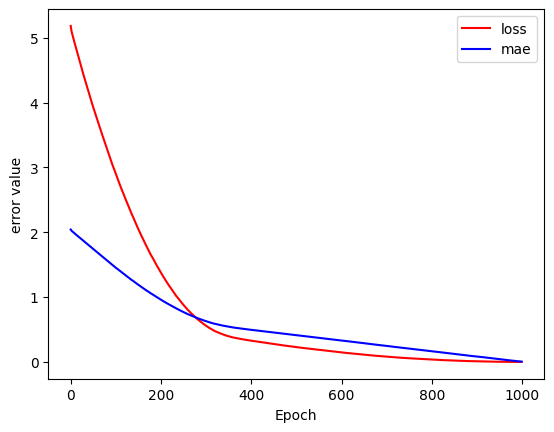

In [30]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('error value')

In [31]:
# 모델 사용
model.predict(np.array([[0],
                        [0.01],
                        [0.02]]))

1/1 [==============================] - 0s 27ms/step


array([[0.33019298],
       [0.3480223 ],
       [0.3658516 ]], dtype=float32)

In [32]:
model.save('model/after_learning.h5')

In [33]:
# 모델 load
from tensorflow.keras.models import load_model
model = load_model('model/after_learning.h5')

In [37]:
y_hat = model.predict([scaled_data_C])
square_error = 0
for h, y in zip(y_hat, scaled_data_F):
    # print(h, y)
    square_error += (h[0]-y)**2
square_error/100 # mean square error (mse)

4/4 [==============================] - 0s 3ms/step


2.7316677048605924e-05

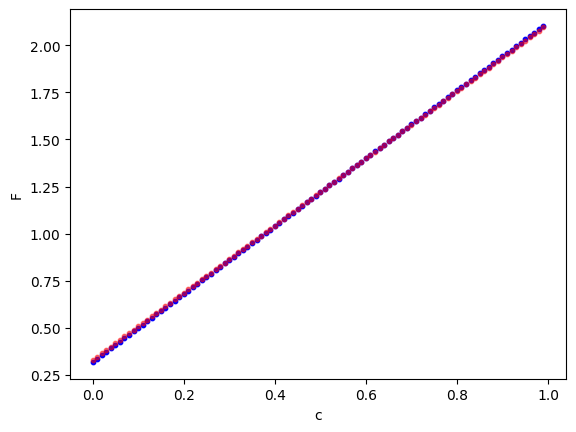

In [40]:
plt.scatter(x=scaled_data_C, y=scaled_data_F, c='b', s=10)
plt.scatter(x=scaled_data_C, y=y_hat, c='r', s=10, alpha=0.5)
plt.xlabel('c')
plt.ylabel('F')
plt.show()

## 2.2 노이즈가 있는 데이터로 실습

In [42]:
# 평균이 0이고 표준편차가 0.1 인 넘파이 배열을 생성(size만큼)
np.random.seed(707)
noise = np.random.normal(0, scale=0.1, size=100)
noised_scaled_data_F = noise + scaled_data_F
noised_scaled_data_F

array([0.27500034, 0.20410134, 0.39498826, 0.27117424, 0.26897164,
       0.35314388, 0.4496784 , 0.42612159, 0.49409646, 0.45740286,
       0.31574183, 0.67996337, 0.46117139, 0.66152189, 0.45319086,
       0.4519712 , 0.73018132, 0.54170904, 0.68386841, 0.75022628,
       0.65735179, 0.76512782, 0.57019861, 0.79130977, 0.62965251,
       0.60058611, 0.81087191, 0.79345666, 0.90825121, 0.80020546,
       0.8489619 , 0.72808603, 0.98336163, 0.78173322, 0.8212351 ,
       1.05542797, 0.86566002, 0.99728791, 1.14628604, 0.93021808,
       0.91091956, 1.20887357, 0.89807223, 1.08124513, 0.95949964,
       1.24417872, 1.47029141, 0.89345844, 1.24009232, 1.26965718,
       1.39203371, 1.20086793, 1.17335862, 1.18484202, 1.26527807,
       1.25914114, 1.25582658, 1.46684352, 1.42267387, 1.38347091,
       1.34554506, 1.45325705, 1.58244673, 1.31622328, 1.38397926,
       1.53624202, 1.36919068, 1.51482044, 1.6480895 , 1.69886349,
       1.60323679, 1.68203012, 1.53758531, 1.57779451, 1.73967

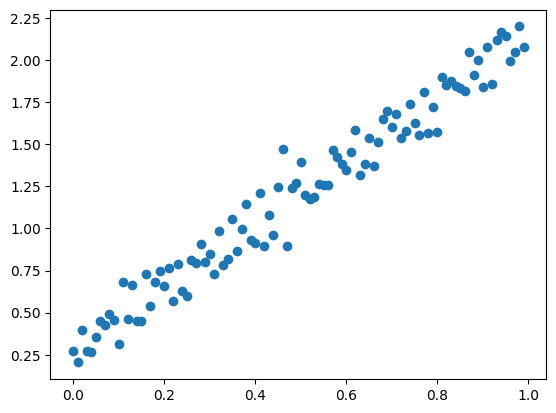

In [44]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F)
plt.show()

In [45]:
# 3. 모델 구성(tensorflow)
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense, Input # 입력값과 출력값으로 layer층 지정
model12 = Sequential()
model12.add(Dense(units=1, input_shape=(1, ))) # units출력갯수, input_shape입력shape
# 4. 학습과정 설정
model12.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
#                손실함수         옵티마이저            평가지표
print(model12.summary())

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


In [46]:
hist2 = model12.fit(scaled_data_C,
                    noised_scaled_data_F,
                    epochs=1000,
                    verbose=1)

Epoch 1/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1372 - mae: 0.3526
Epoch 2/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.1291 - mae: 0.3411
Epoch 3/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1237 - mae: 0.3334
Epoch 4/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1191 - mae: 0.3266
Epoch 5/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1147 - mae: 0.3199
Epoch 6/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1109 - mae: 0.3141
Epoch 7/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1071 - mae: 0.3080
Epoch 8/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1032 - mae: 0.3018
Epoch 9/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0998 - mae: 0.2963
Epoch 10/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0964 - mae: 0.2905
Epoch 11/1000
4/4 [==============================] - 0s 2ms/step - lo

4/4 [==============================] - 0s 2ms/step - loss: 0.0112 - mae: 0.0888
Epoch 89/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0112 - mae: 0.0889
Epoch 90/1000
4/4 [==============================] - 0s 4ms/step - loss: 0.0112 - mae: 0.0888
Epoch 91/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0112 - mae: 0.0888
Epoch 92/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0112 - mae: 0.0887
Epoch 93/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0112 - mae: 0.0887
Epoch 94/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0112 - mae: 0.0887
Epoch 95/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0112 - mae: 0.0887
Epoch 96/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0112 - mae: 0.0887
Epoch 97/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0112 - mae: 0.0888
Epoch 98/1000
4/4 [==============================] - 0s 2ms/step - loss: 0

4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0881
Epoch 175/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0879
Epoch 176/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0880
Epoch 177/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0880
Epoch 178/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0881
Epoch 179/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0881
Epoch 180/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0881
Epoch 181/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0880
Epoch 182/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0880
Epoch 183/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0882
Epoch 184/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0879
Epoch 261/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 262/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 263/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0877
Epoch 264/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 265/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 266/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0879
Epoch 267/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0878
Epoch 268/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0878
Epoch 269/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 270/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0879
Epoch 347/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0877
Epoch 348/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0877
Epoch 349/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 350/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 351/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 352/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0877
Epoch 353/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 354/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 355/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 356/1000
4/4 [==============================] - 0s 2ms/step

...

4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0877
Epoch 605/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0878
Epoch 606/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0878
Epoch 607/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0878
Epoch 608/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 609/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0109 - mae: 0.0877
Epoch 610/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0878
Epoch 611/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 612/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 613/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0879
Epoch 614/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 691/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0877
Epoch 692/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 693/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0109 - mae: 0.0878
Epoch 694/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 695/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0877
Epoch 696/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 697/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0109 - mae: 0.0877
Epoch 698/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0109 - mae: 0.0877
Epoch 699/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0109 - mae: 0.0877
Epoch 700/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0878
Epoch 777/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0877
Epoch 778/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 779/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0877
Epoch 780/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 781/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 782/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 783/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 784/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 785/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 786/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0876
Epoch 863/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0109 - mae: 0.0876
Epoch 864/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0109 - mae: 0.0877
Epoch 865/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0109 - mae: 0.0877
Epoch 866/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0878
Epoch 867/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0879
Epoch 868/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0109 - mae: 0.0878
Epoch 869/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 870/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0876
Epoch 871/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0877
Epoch 872/1000
4/4 [==============================] - 0s 3ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 949/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 950/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 951/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 952/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 953/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 954/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 955/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 956/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 957/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0879
Epoch 958/1000
4/4 [==============================] - 0s 3ms/step

In [47]:
hist2.history.keys()

dict_keys(['loss', 'mae'])

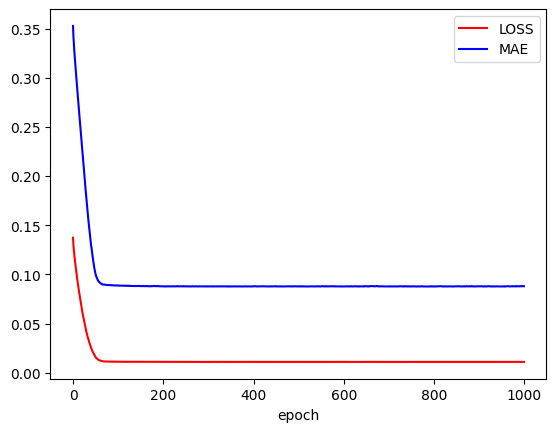

In [49]:
plt.plot(hist2.history['loss'], 'r', label='LOSS')
plt.plot(hist2.history['mae'], 'b', label='MAE')
plt.legend()
plt.xlabel('epoch')
plt.show()

In [54]:
y_hat = model12.predict([scaled_data_C])
square_error = 0
for h, y in zip(y_hat, noised_scaled_data_F):
    # print(h, y)
    square_error += (h[0]-y)**2
square_error/100 # mse

4/4 [==============================] - 0s 2ms/step


0.010994784644475024

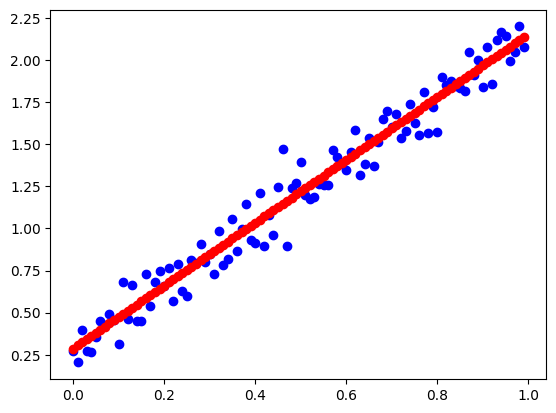

In [55]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F, c='b')
plt.scatter(x=scaled_data_C, y=y_hat, c='r')